# Lab 8: Representing Document Concepts with Embeddings 
## Team: Trojan Trio
## Member: Jinyao Yang, Qianshu Peng, Sen Pang

This notebook format was approved by TA Tanya via email for this assignment. A corresponding .py script containing only the code has also been provided
as requested.

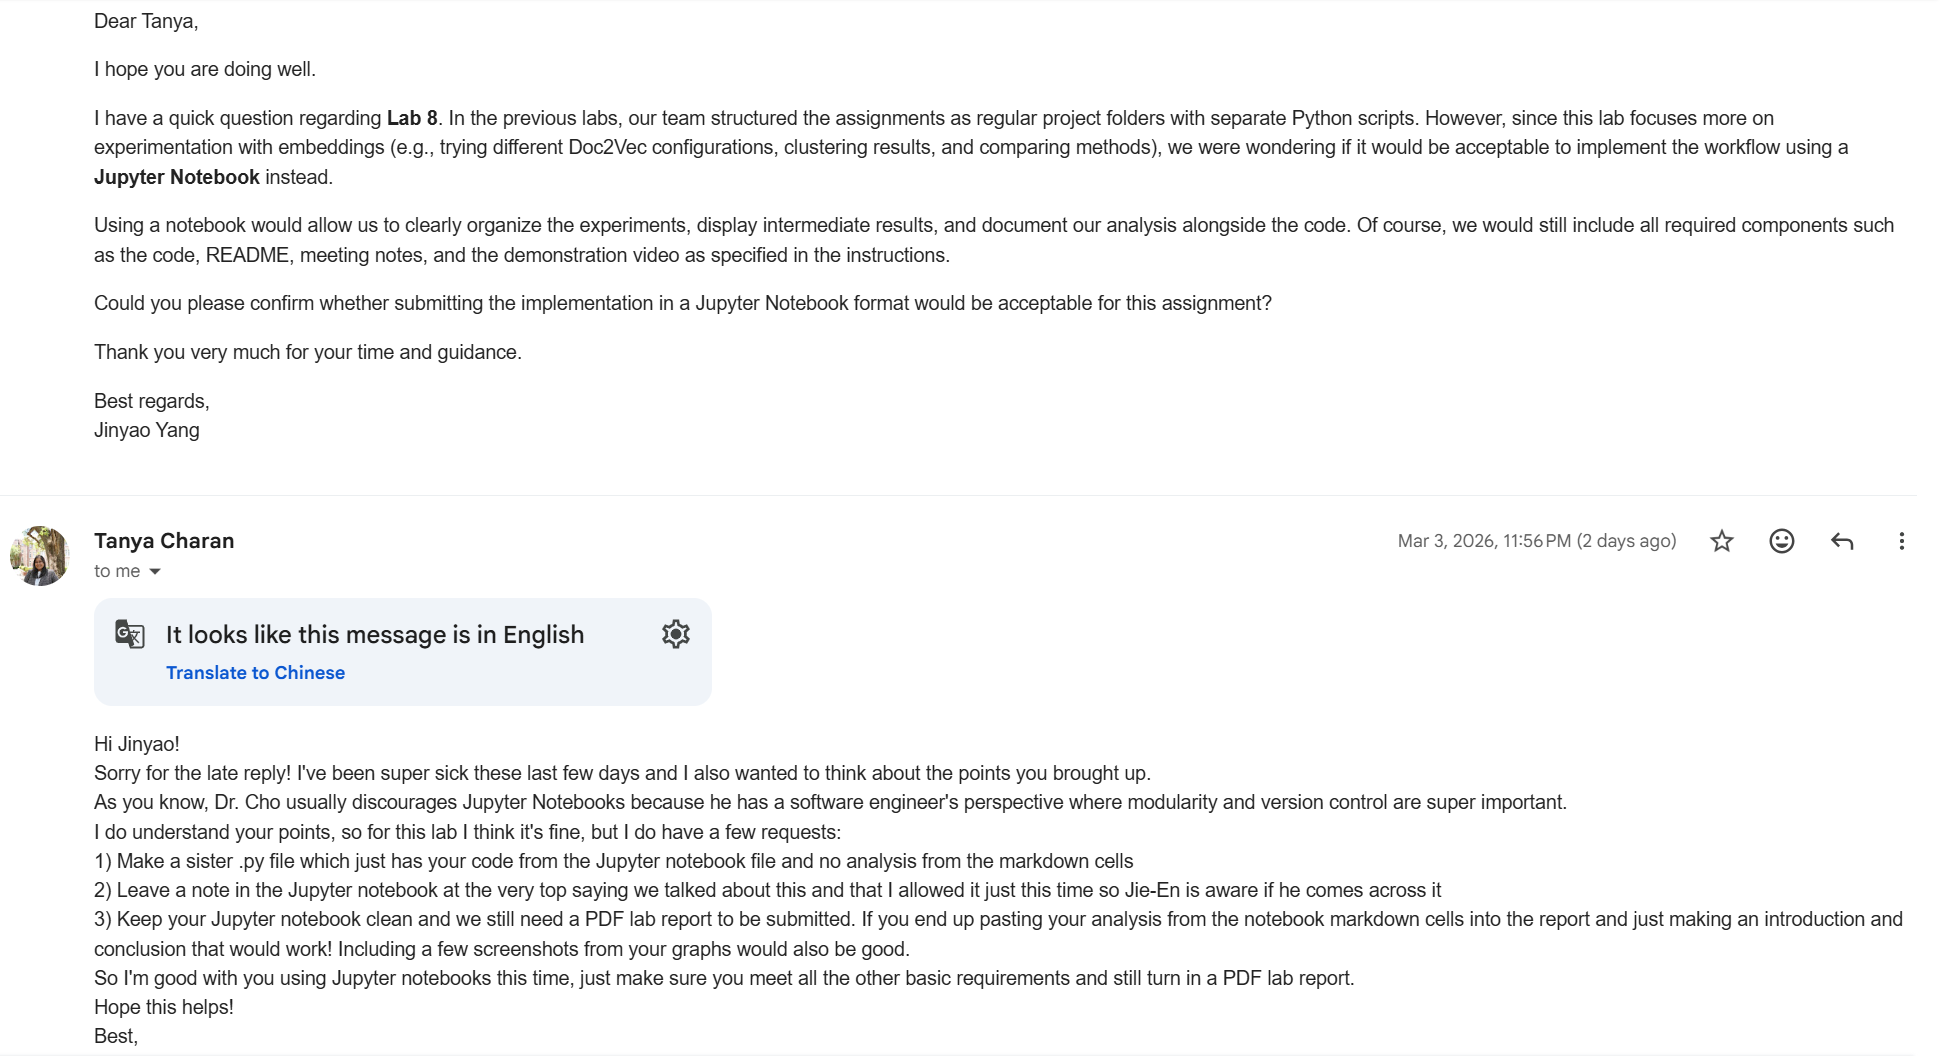

In [1]:
# Standard library
import json
import re
import string
import random
from pathlib import Path
from collections import defaultdict, Counter

# Data processing
import numpy as np
import pandas as pd

# Embedding models (Gensim)
from gensim.models import Doc2Vec, Word2Vec
from gensim.models.doc2vec import TaggedDocument
from gensim.parsing.preprocessing import STOPWORDS

# Clustering and evaluation (scikit-learn)
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

## Load Data

In [2]:
DATA_PATH = Path("posts_lab5_5000.json")

with open(DATA_PATH, "r", encoding="utf-8") as f:
    posts = json.load(f)

assert isinstance(posts, list), "Expected a JSON list (array) of posts."
print("Total posts:", len(posts))

texts = [p.get("final_text", "").strip() for p in posts if isinstance(p, dict)]
texts = [t for t in texts if t]
print("Non-empty texts:", len(texts))

print("Sample keys:", list(posts[0].keys()) if posts else "EMPTY POSTS")

lengths = [len(t.split()) for t in texts]
if lengths:
    print("Min words:", min(lengths))
    print("Max words:", max(lengths))
    print("Average words:", sum(lengths)/len(lengths))
else:
    print("No non-empty texts found, cannot compute length stats.")

Total posts: 5000
Non-empty texts: 5000
Sample keys: ['fullname', 'post_id', 'subreddit', 'title', 'author', 'author_raw', 'created_utc', 'created', 'permalink', 'out_url', 'domain', 'score', 'num_comments', 'is_self', 'body', 'final_text', 'is_image', 'is_gallery', 'image_url', 'gallery_urls', 'thumbnail', 'over_18', 'link_flair_text', 'ocr_text', 'keywords', 'topic']
Min words: 1
Max words: 3398
Average words: 71.8066


## Preprocessing

In [3]:
def clean_text(text):
    text = text or ""
    text = text.lower()                      
    text = re.sub(r"http\S+", " ", text)     
    text = re.sub(r"<[^>]+>", " ", text)     
    text = re.sub(r"[^a-z0-9\s]", " ", text) 
    text = re.sub(r"\s+", " ", text)       
    return text.strip()

docs = []

for p in posts:
    text = clean_text(p.get("final_text", ""))

    if len(text.split()) > 3:  
        docs.append(text)
print("Documents:", len(docs))

lengths = [len(d.split()) for d in docs]
print("Min words:", min(lengths))
print("Max words:", max(lengths))
print("Average words:", sum(lengths)/len(lengths))

Documents: 4986
Min words: 4
Max words: 4846
Average words: 75.03489771359807


In [4]:
def tokenize(text):
    tokens = text.split()  
    return tokens

tokenized_docs = [tokenize(d) for d in docs if d]

print("Number of documents:", len(tokenized_docs))

lengths = [len(t) for t in tokenized_docs]
print("Min tokens:", min(lengths))
print("Max tokens:", max(lengths))
print("Avg tokens:", sum(lengths)/len(lengths))

Number of documents: 4986
Min tokens: 4
Max tokens: 4846
Avg tokens: 75.03489771359807


## Document Clustering Functions

In [5]:
def cluster_docs_cosine(X, k):
    return AgglomerativeClustering(
        n_clusters=k,
        metric="cosine",
        linkage="average"
    ).fit_predict(X)

def cluster_docs_cosine_threshold(X, distance_threshold=0.7):
    return AgglomerativeClustering(
        n_clusters=None,
        metric="cosine",
        linkage="average",
        distance_threshold=distance_threshold
    ).fit_predict(X)

## Task 1: Doc2Vec Document Embedding and Clustering

In [6]:
tagged_docs = [
    TaggedDocument(words=doc, tags=[i])
    for i, doc in enumerate(tokenized_docs)
]

print("Sample TaggedDocument:", tagged_docs[0])

Sample TaggedDocument: TaggedDocument<['big', 'blimp', 'uses', 'blades', 'to', 'pull', 'wind', 'power', 'out', 'of', 'the', 'sky'], [0]>


In [7]:
def train_doc2vec_get_X(
    tagged_docs,
    vector_size,
    min_count,
    epochs,
    window=8,
    workers=1,   
    dm=1,
    negative=5,
    hs=0,
    sample=1e-4,
    seed=42,
):
    model = Doc2Vec(
        vector_size=vector_size,
        min_count=min_count,
        epochs=epochs,
        window=window,
        workers=workers,
        dm=dm,
        negative=negative,
        hs=hs,
        sample=sample,
        seed=seed
    )

    model.build_vocab(tagged_docs)
    model.train(tagged_docs, total_examples=model.corpus_count, epochs=epochs)

    vectors = np.vstack([model.dv[i] for i in range(len(tagged_docs))]).astype(np.float32)
    X = normalize(vectors, norm="l2")
    return model, vectors, X

In [8]:
K_FIXED = 8
THR_FIXED = 0.55

task1_results = []

task1_configs = [
    ("A", 50, 3, 30, 1),
    ("B", 100, 3, 30, 1),
    ("C", 300, 3, 30, 1),
]

models = {}
vectors_map = {}
X_map = {}
labels_map = {}

for name, vs, mc, ep, dm in task1_configs:
    print(f"Running Model {name}: vector_size={vs}, min_count={mc}, epochs={ep}, dm={dm}")

    model, vectors, X = train_doc2vec_get_X(
        tagged_docs,
        vector_size=vs,
        min_count=mc,
        epochs=ep,
        dm=dm,
        seed=42,
        workers=1
    )

    labels = cluster_docs_cosine(X, k=K_FIXED)
    sil = silhouette_score(X, labels, metric="cosine")

    models[name] = model
    vectors_map[name] = vectors
    X_map[name] = X
    labels_map[name] = labels

    print(f"Model {name} k={K_FIXED}, silhouette (cosine) = {sil:.6f}\n")

    task1_results.append({
        "Model": name,
        "vector_size": vs,
        "min_count": mc,
        "epochs": ep,
        "dm": dm,
        "best_threshold": THR_FIXED,  
        "silhouette_cosine": sil,
        "doc_labels": labels
    })

df_task1 = (
    pd.DataFrame(
        [{
            "Model": r["Model"],
            "vector_size": r["vector_size"],
            "min_count": r["min_count"],
            "epochs": r["epochs"],
            "dm": r["dm"],
            "silhouette_cosine": r["silhouette_cosine"]
        }
        for r in task1_results]
    )
    .sort_values("silhouette_cosine", ascending=False)
    .reset_index(drop=True)
)

df_task1

Running Model A: vector_size=50, min_count=3, epochs=30, dm=1
Model A k=8, silhouette (cosine) = 0.265873

Running Model B: vector_size=100, min_count=3, epochs=30, dm=1
Model B k=8, silhouette (cosine) = 0.273393

Running Model C: vector_size=300, min_count=3, epochs=30, dm=1
Model C k=8, silhouette (cosine) = 0.311466



,Model,vector_size,min_count,epochs,dm,silhouette_cosine
0,C,300,3,30,1,0.311466
1,B,100,3,30,1,0.273393
2,A,50,3,30,1,0.265873


### Doc2Vec Clustering Results and Analysis

Three Doc2Vec configurations were evaluated using different vector sizes (50, 100, and 300) while keeping other hyperparameters constant (min_count=3, epochs=30, PV-DM architecture).

The results show that Model C (vector_size=300) achieved the highest silhouette score (≈0.311), indicating the most coherent clustering structure among the tested configurations.

Model B (vector_size=100) produced slightly lower performance (≈0.273), while Model A (vector_size=50) obtained the lowest score (≈0.266).

These results suggest that larger embedding dimensions allow Doc2Vec to capture richer semantic relationships between documents, which improves cluster separability. Lower-dimensional embeddings may not provide sufficient representational capacity to distinguish different discussion topics in the dataset.

Overall, the configuration with vector_size=300 provided the best clustering performance for this Reddit dataset.

## Task 2: Word2Vec-Based Document Representation and Clustering

In [9]:
sentences = tokenized_docs   # list[list[str]]
print("Number of sentences:", len(sentences))

Number of sentences: 4986


In [10]:
w2v = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=3,
    workers=1,   
    sg=1,
    epochs=10,
    seed=42
)

print("Vocab size:", len(w2v.wv))
print("Vector size:", w2v.vector_size)

Vocab size: 8910
Vector size: 100


In [11]:
words = list(w2v.wv.index_to_key)

word_vecs = np.array([
    w2v.wv[w] for w in words
], dtype=np.float32)

print("len(words) =", len(words))
print("word_vecs shape =", word_vecs.shape)

len(words) = 8910
word_vecs shape = (8910, 100)


In [12]:
def cluster_words_into_bins(word_vecs, k):
    word_vecs_norm = normalize(word_vecs, norm="l2")

    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    word_labels = km.fit_predict(word_vecs_norm)

    return word_labels

def build_word_to_bin(words, word_labels):
    assert len(words) == len(word_labels)
    return {w: int(lbl) for w, lbl in zip(words, word_labels)}

def docs_to_bin_freq_vectors(tokenized_docs, word_to_bin, k):
    X = np.zeros((len(tokenized_docs), k), dtype=np.float32)

    for i, tokens in enumerate(tokenized_docs):
        bins = [word_to_bin[t] for t in tokens if t in word_to_bin]
        if not bins:
            continue
        for b in bins:
            X[i, b] += 1.0
        X[i] /= len(bins)  # normalize by doc length

    return X

In [13]:
task2_results = []
task2_configs = [("A", 50), ("B", 100), ("C", 300)]

words = list(w2v.wv.index_to_key)
word_vecs = np.array([w2v.wv[w] for w in words], dtype=np.float32)

for name, num_bins in task2_configs:
    print(f"Running Model {name}: num_bins={num_bins}")

    # word -> bin
    word_labels = cluster_words_into_bins(word_vecs, num_bins)  
    word_to_bin = build_word_to_bin(words, word_labels)

    # doc vectors
    X_doc = docs_to_bin_freq_vectors(tokenized_docs, word_to_bin, num_bins)
    X_doc = normalize(X_doc, norm="l2")

    doc_labels = cluster_docs_cosine(X_doc, k=K_FIXED)
    sil = silhouette_score(X_doc, doc_labels, metric="cosine")

    print(f"Model {name} k={K_FIXED}, silhouette (cosine) = {sil:.6f}\n")

    task2_results.append({
        "Model": name,
        "num_bins": num_bins,
        "best_threshold": THR_FIXED, 
        "silhouette_cosine": sil,
        "doc_labels": doc_labels
    })

df_task2 = (
    pd.DataFrame(
        [{
            "Model": r["Model"],
            "num_bins": r["num_bins"],
            "silhouette_cosine": r["silhouette_cosine"]
        }
        for r in task2_results]
    )
    .sort_values("silhouette_cosine", ascending=False)
    .reset_index(drop=True)
)

df_task2

Running Model A: num_bins=50


D:\python\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\python\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "D:\python\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\python\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "D:\python\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^

Model A k=8, silhouette (cosine) = 0.224287

Running Model B: num_bins=100
Model B k=8, silhouette (cosine) = 0.275504

Running Model C: num_bins=300
Model C k=8, silhouette (cosine) = 0.109152



,Model,num_bins,silhouette_cosine
0,B,100,0.275504
1,A,50,0.224287
2,C,300,0.109152


### Word2Vec Clustering Results and Analysis

Three different bin sizes (50, 100, and 300) were evaluated for the Word2Vec-based document representation while keeping other parameters fixed.

The results show that the configuration with 100 bins achieved the highest silhouette score (≈0.275), indicating the best clustering quality among the tested configurations.

Using 50 bins produced slightly lower performance (≈0.224), likely because the document representation becomes too coarse and cannot capture sufficient semantic distinctions between documents.

In contrast, increasing the number of bins to 300 significantly reduced clustering quality (≈0.109). This is likely because the document vectors become increasingly sparse when the number of bins is large, which makes the clustering less stable and reduces cluster separability.

Overall, a moderate bin size (100) provides the best balance between semantic representation and vector sparsity for this dataset.

## Comparative Analysis

In [14]:
COMMON = {
    "like", "new", "use", "time", "people", "know", "want", "work",
    "says", "year", "years",

    # frequent non-informative words in this dataset
    "data", "model", "models", "security", "job", "science", "learning",
    "think", "need", "way", "questions",

    # add these to avoid "giant cluster" top-words being dominated by chatty terms
    "code", "real", "actually", "experience", "working", "company", "tools", "good"
}

def show_cluster_samples(labels, docs, tokenized_docs, n=5, max_len=140, seed=42):
    buckets = defaultdict(list)

    for i, c in enumerate(labels):
        buckets[int(c)].append(i)

    for c in sorted(buckets.keys()):
        idxs = buckets[c]

        print(f"\n=== Cluster {c} (size={len(idxs)}) ===")

        if not idxs:
            print("No documents")
            continue

        words = []
        for idx in idxs:
            for w in tokenized_docs[idx]:
                if w in STOPWORDS:
                    continue
                if w in COMMON:
                    continue
                if len(w) < 3:
                    continue
                if w.isdigit():
                    continue
                words.append(w)

        top_words = Counter(words).most_common(8)
        print("Top words:", top_words)

        random.Random(seed + c).shuffle(idxs)

        for idx in idxs[:n]:
            print("-", docs[idx][:max_len])

In [15]:
print("=== Model A samples ===")
show_cluster_samples(labels_map["A"], docs, tokenized_docs)

print("\n=== Model B samples ===")
show_cluster_samples(labels_map["B"], docs, tokenized_docs)

print("\n=== Model C samples ===")
show_cluster_samples(labels_map["C"], docs, tokenized_docs)

=== Model A samples ===

=== Cluster 0 (size=4858) ===
Top words: [('looking', 304), ('systems', 300), ('help', 300), ('things', 296), ('agent', 287), ('lot', 287), ('right', 285), ('understand', 284)]
- grok generates fake taylor swift nudes without being asked
- exploratory analysis of 12 frontier llm s across 100s of hours shows o3 highest type token ratio lexical diversity gpt 5 most formal languag
- hello everyone staying on top of the constantly growing skill requirements in data science is quite a challenge to manage my own learning an
- have a bachelor s degree not related to cs so considered joining the military as an officer i do understand that a cyber security related jo
- does a computer port communicate or is it just the intermediary or facilitator of communication what defines communication does a usb port c

=== Cluster 1 (size=22) ===
Top words: [('wing', 37), ('report', 37), ('violence', 24), ('right', 22), ('read', 22), ('grok', 22), ('stats', 21), ('key', 20)]
- you

In [16]:
for r in task2_results:
    print(f"\n=== Model {r['Model']} samples ===")
    show_cluster_samples(r["doc_labels"], docs, tokenized_docs)


=== Model A samples ===

=== Cluster 0 (size=4892) ===
Top words: [('right', 314), ('help', 311), ('looking', 310), ('systems', 307), ('things', 306), ('agent', 294), ('lot', 293), ('cybersecurity', 292)]
- i have 8gb vram on a 1070ti plus 16 gb of ddr3 will i be able to generate a usable result and what model do you guys think i should use if i
- clever contact lenses watch for glaucoma even when wearers eyes are shut
- mandiant releases rainbow table that cracks weak admin password in 12 hours
- simulating real life with 6 autonomous ai agents
- the great stay here s the new reality for tech workers

=== Cluster 1 (size=12) ===
Top words: [('faster', 3), ('tech', 2), ('ultrasound', 1), ('pad', 1), ('aims', 1), ('prenatal', 1), ('visits', 1), ('unpleasant', 1)]
- darpa greenlights bell s rotor folding x plane
- aurora s driverless trucks can now travel farther distances faster than human drivers techcrunch
- back bending robodog climbs tight spaces faster
- oracle keeps denying more 

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_clusters_pca(X, labels, title="Clusters (PCA 2D)"):
    labels = np.asarray(labels)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    n_clusters = len(set(labels))
    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis", s=10)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"{title} | clusters={n_clusters}")
    plt.colorbar(label="Cluster")
    plt.show()

D:\python\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


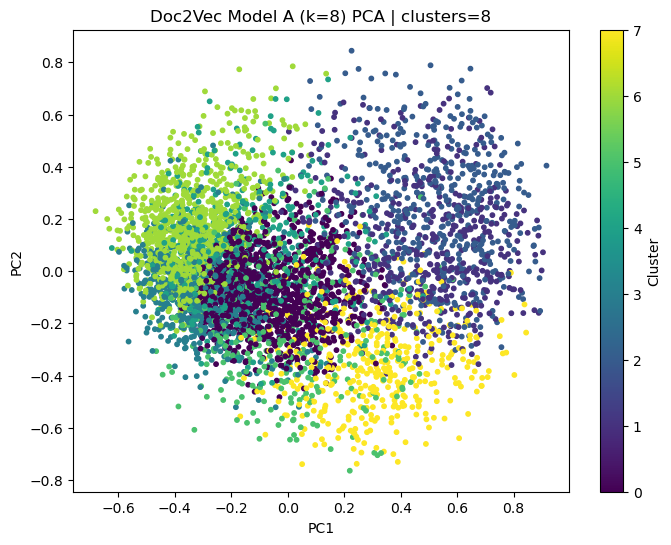

In [18]:
labels_k8 = KMeans(n_clusters=8, random_state=42).fit_predict(X_map["A"])
plot_clusters_pca(X_map["A"], labels_k8, "Doc2Vec Model A (k=8) PCA")

D:\python\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


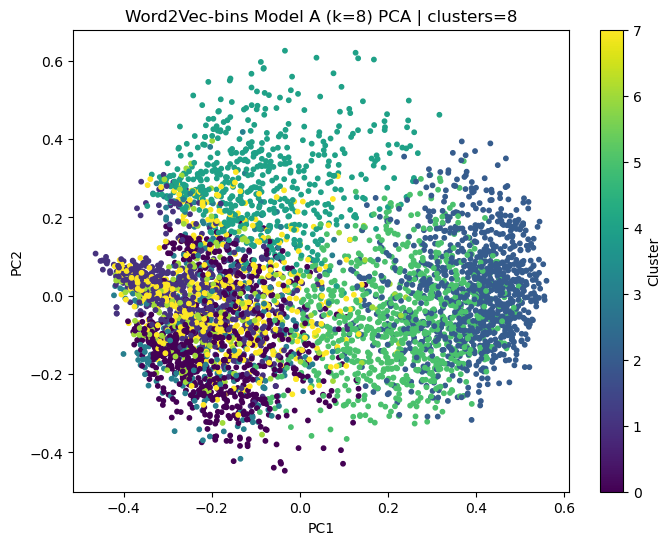

In [19]:
labels_k8 = KMeans(n_clusters=8, random_state=42).fit_predict(X_doc)
plot_clusters_pca(X_doc, labels_k8, "Word2Vec-bins Model A (k=8) PCA")

For quantitative evaluation, we apply agglomerative clustering with cosine distance and a fixed number of clusters (𝑘 = 8). Clustering quality is evaluated using the cosine-based silhouette score.

For visualization purposes, PCA projections are colored using KMeans with 𝑘 = 8. KMeans is used only to assign colors to points in the 2D projection, providing clearer visual separation. The clustering results reported in the evaluation are still based on agglomerative clustering.

## Conclusion

In this assignment, we compared two approaches for clustering short technology-related texts: Doc2Vec document embeddings and Word2Vec bin-frequency representations derived from clustered word embeddings.

Quantitative evaluation using cosine-based silhouette scores showed that the Doc2Vec representation achieved the best overall clustering performance. The best Doc2Vec configuration (vector_size = 300) obtained a silhouette score of approximately 0.311, while the best Word2Vec bin-frequency configuration (100 bins) achieved a slightly lower score of approximately 0.275.

For the Word2Vec-based representation, moderate dimensionality provided the best clustering quality. Using 100 bins produced the highest silhouette score, while increasing the number of bins to 300 significantly reduced clustering quality, likely due to increased sparsity in the document vectors.

Qualitative inspection of clusters revealed meaningful topical groupings in both approaches, including discussions related to cybersecurity, medical technology, and physics or energy research.

Overall, the results suggest that Doc2Vec document embeddings are more effective at capturing the semantic structure of short technology-related texts in this dataset, although both approaches were able to identify coherent thematic clusters.

In [21]:
!jupyter nbconvert --to script "lab 8.ipynb"

[NbConvertApp] Converting notebook lab 8.ipynb to script
[NbConvertApp] Writing 14936 bytes to lab 8.py
